In [ ]:
# -------------------------------
# 1. Imports and Setup
# -------------------------------
import os
import io
import cv2
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from ipywidgets import FileUpload
from IPython.display import display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

# -------------------------------
# 2. Model Loading
# -------------------------------
from torchvision.models import resnet18, ResNet18_Weights

# Load model with pre-trained weights
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

model.fc = torch.nn.Linear(model.fc.in_features, len(class_names))
model.load_state_dict(torch.load("best_resnet18_model.pth", map_location=device))
model = model.to(device)
model.eval()

# -------------------------------
# 3. Dataset & Dataloader
# -------------------------------
val_df = pd.read_csv("val_df_processed.csv")

class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        image_path = self.data.iloc[idx]['image_path']
        label = self.data.iloc[idx]['label_idx']
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_loader = DataLoader(SkinLesionDataset(val_df, transform=preprocess),
                        batch_size=16, shuffle=False)

# -------------------------------
# 4. Evaluation & Metrics
# -------------------------------
def evaluate_model(model, val_loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return y_true, y_pred

y_true, y_pred = evaluate_model(model, val_loader)

# Save metrics
metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
    "recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
    "f1_score": f1_score(y_true, y_pred, average='weighted', zero_division=0)
}

for k, v in metrics.items():
    print(f"{k.capitalize()}: {v:.4f}")

pd.DataFrame(metrics.items(), columns=["Metric", "Value"]).to_csv("metrics_summary.csv", index=False)

# -------------------------------
# 5. Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# 6. ROC Curves per Class
# -------------------------------
# Get prediction probabilities
model.eval()
all_probs, all_labels = [], []
softmax = torch.nn.Softmax(dim=1)

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = softmax(outputs).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
all_labels_onehot = label_binarize(all_labels, classes=range(len(class_names)))

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(all_labels_onehot[:, i], all_probs[:, i])
    auc_score = roc_auc_score(all_labels_onehot[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-Class ROC Curves")
plt.legend(loc='lower right')
plt.show()

# -------------------------------
# 7. Grad-CAM Visualization
# -------------------------------
output_folder = "gradcam_outputs"
os.makedirs(output_folder, exist_ok=True)

def generate_gradcam(image_path, model, target_layer):
    rgb_img = Image.open(image_path).convert("RGB")
    input_tensor = preprocess(rgb_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        pred_class = probs.argmax(dim=1).item()

    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(pred_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    rgb_img_np = np.array(rgb_img) / 255.0
    visualization = show_cam_on_image(rgb_img_np, grayscale_cam, use_rgb=True)

    return rgb_img, visualization, pred_class, probs[0, pred_class].item()

target_layer = model.layer4[-1]
sample_images = val_df.sample(5)['image_path'].values

plt.figure(figsize=(12, 8))
for i, img_path in enumerate(sample_images):
    orig_img, cam_img, pred_cls, conf = generate_gradcam(img_path, model, target_layer)
    
    plt.subplot(2, 5, i+1)
    plt.imshow(orig_img)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2, 5, i+6)
    plt.imshow(cam_img)
    plt.axis("off")
    plt.title(f"{class_names[pred_cls]}\n({conf:.2f})")

    # Save CAM image
    cam_img_bgr = cv2.cvtColor(cam_img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(os.path.join(output_folder, f"{os.path.basename(img_path)}_cam.png"), cam_img_bgr)

plt.tight_layout()
plt.show()

# -------------------------------
# 8. Custom Image Prediction (User Upload)
# -------------------------------
upload = FileUpload(accept='image/*', multiple=True)
display(upload)

if upload.value:
    plt.figure(figsize=(15, 5))
    for i, file_info in enumerate(upload.value):
        img = Image.open(io.BytesIO(file_info['content'])).convert("RGB")
        input_tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = model(input_tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            pred_idx = torch.argmax(probs, dim=1).item()
            conf = probs[0, pred_idx].item()

        plt.subplot(1, len(upload.value), i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{class_names[pred_idx]}\n({conf*100:.1f}%)")
    plt.tight_layout()
    plt.show()
else:
    print("Please upload at least one image.")


Evaluating:  17%|█▋        | 21/126 [00:04<00:22,  4.58it/s]

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision import transforms
from PIL import Image
from ipywidgets import FileUpload, VBox, Output
from PIL import Image
import io

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class names
class_names = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [3]:
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
import pandas as pd
from PIL import Image
from torchvision import transforms

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class names
class_names = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

# Recreate your model architecture exactly as in Notebook 3
model = models.resnet18(pretrained=False)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

# Load the trained weights
model.load_state_dict(torch.load("best_resnet18_model.pth", map_location=device))
model = model.to(device)
model.eval()

# Prepare your validation dataframe and DataLoader (adjust paths and filenames)
val_df = pd.read_csv("val_df_processed.csv")

# Define Dataset class (same as your previous notebook)
class SkinLesionDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        image_path = self.data.iloc[idx]['image_path']
        label = self.data.iloc[idx]['label_idx']
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Validation transforms (same as before)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_ds = SkinLesionDataset(val_df, transform=preprocess)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)

# Now you’re ready to run evaluation, metrics, and Grad-CAM code below


/usr/local/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [4]:
def evaluate_model(model, val_loader, class_names):
    model.eval()
    correct, total = 0, 0
    y_true = []
    y_pred = []
    val_bar = tqdm(val_loader, desc="Validating", leave=False)

    with torch.no_grad():
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

            val_bar.set_postfix(accuracy=correct / total)

    accuracy = correct / total
    print(f"Validation Accuracy: {accuracy:.4f}")
    return y_true, y_pred

In [5]:
# 1. Metrics computation
# Run evaluation on validation set to get true and predicted labels
y_true, y_pred = evaluate_model(model, val_loader, class_names)

# Assuming y_true, y_pred available (from Notebook 3's evaluate_model)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1 Score (weighted): {f1:.4f}")


Validation Accuracy: 0.0844
Accuracy: 0.0844
Precision (weighted): 0.5020
Recall (weighted): 0.0844
F1 Score (weighted): 0.1010


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming y_true and y_pred are already available from evaluation
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# Now save metrics
metrics_df = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall', 'f1_score'],
    'value': [accuracy, precision, recall, f1]
})
metrics_df.to_csv("metrics_summary.csv", index=False)


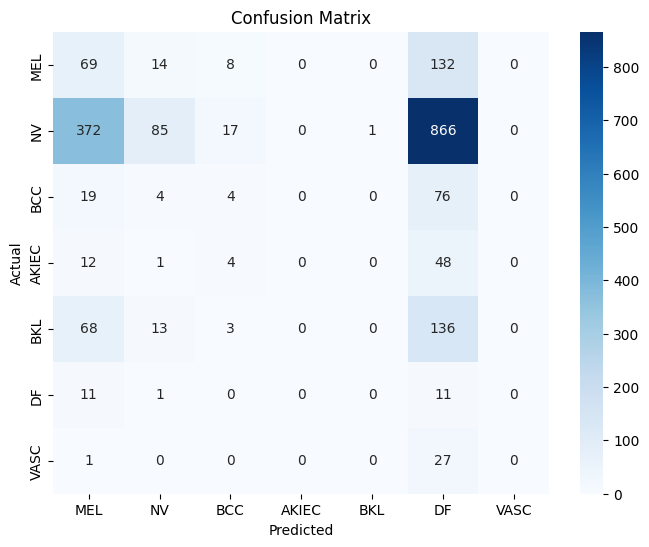

In [7]:
# 2. Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


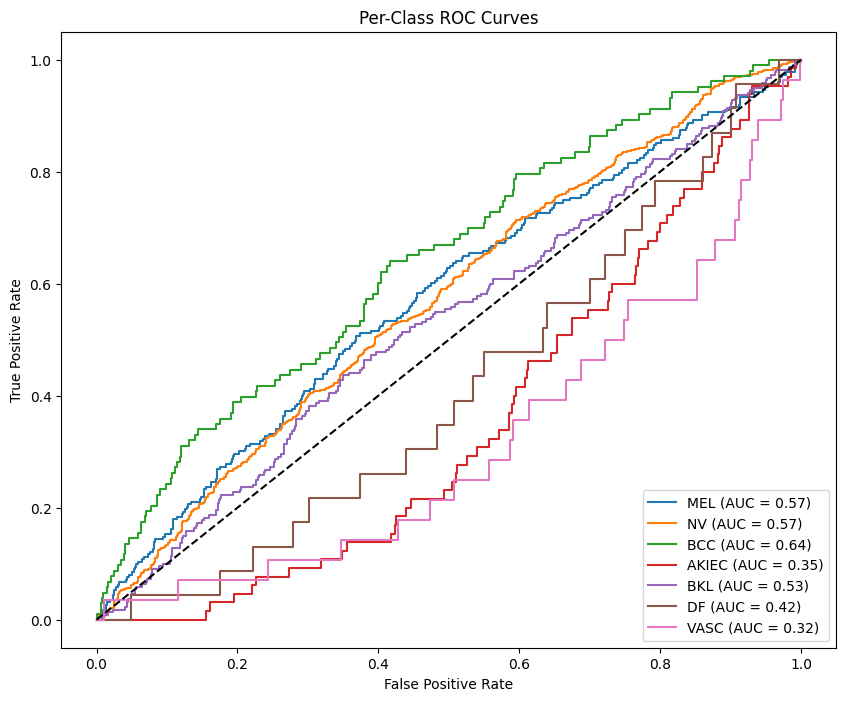

In [8]:
# 3. Per-class ROC AUC and ROC Curves
# For multi-class ROC AUC, need one-hot true labels and prediction scores (probabilities)

# Collect all predictions probabilities on validation set
model.eval()
all_probs = []
all_labels = []

softmax = torch.nn.Softmax(dim=1)

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = softmax(outputs).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

# One-hot encode true labels
from sklearn.preprocessing import label_binarize
all_labels_onehot = label_binarize(all_labels, classes=range(len(class_names)))

# Compute ROC AUC per class
roc_auc = {}
plt.figure(figsize=(10,8))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(all_labels_onehot[:, i], all_probs[:, i])
    auc_score = roc_auc_score(all_labels_onehot[:, i], all_probs[:, i])
    roc_auc[class_name] = auc_score
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {auc_score:.2f})")

plt.plot([0,1], [0,1], 'k--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-Class ROC Curves")
plt.legend(loc='lower right')
plt.show()


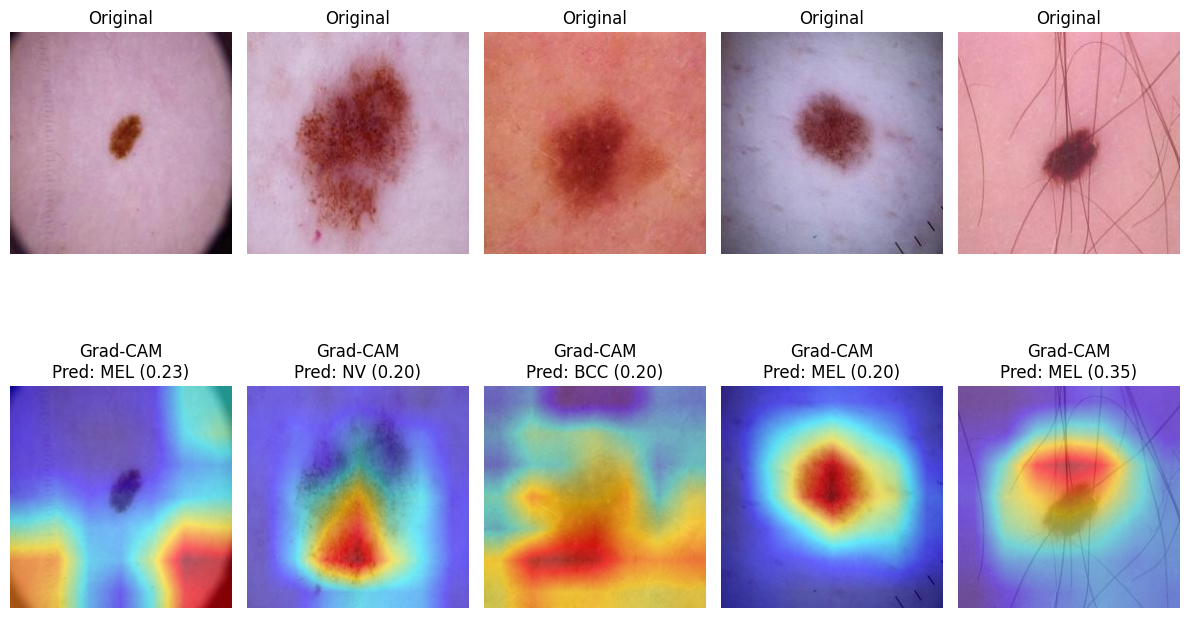

✅ Saved Grad-CAM images to folder: gradcam_outputs


In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import torchvision.transforms as transforms

# Setup output folder
output_folder = "gradcam_outputs"
os.makedirs(output_folder, exist_ok=True)

# Setup transforms for raw images (no normalization)
raw_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# Function to load image and get model prediction + Grad-CAM heatmap
def generate_gradcam(image_path, model, target_layer, class_idx=None):
    model.eval()
    rgb_img = Image.open(image_path).convert("RGB")
    input_tensor = raw_transform(rgb_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        pred_class = probs.argmax(dim=1).item()

    target_class = class_idx if class_idx is not None else pred_class

    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(target_class)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    rgb_img_np = np.array(rgb_img) / 255.0

    visualization = show_cam_on_image(rgb_img_np, grayscale_cam, use_rgb=True)
    return rgb_img, visualization, pred_class, probs[0, target_class].item()

# Pick the last conv layer of ResNet18
target_layer = model.layer4[-1]

# Sample 5 images from validation dataframe
sample_images = val_df.sample(5)['image_path'].values

plt.figure(figsize=(12, 8))
for i, img_path in enumerate(sample_images):
    original_img, cam_img, pred_cls, pred_prob = generate_gradcam(img_path, model, target_layer)

    # Save Grad-CAM overlay image as PNG
    cam_img_bgr = cv2.cvtColor(cam_img, cv2.COLOR_RGB2BGR)
    image_name = os.path.basename(img_path)
    output_path = os.path.join(output_folder, f"{image_name}_cam.png")
    cv2.imwrite(output_path, cam_img_bgr)

    # Display original and Grad-CAM images
    plt.subplot(2, 5, i+1)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    plt.imshow(cam_img)
    plt.title(f"Grad-CAM\nPred: {class_names[pred_cls]} ({pred_prob:.2f})")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"✅ Saved Grad-CAM images to folder: {output_folder}")


In [10]:
# Upload a skin lesion image using the file widget
from ipywidgets import FileUpload
from IPython.display import display
from PIL import Image
import io

upload = FileUpload(accept='image/*', multiple=True)
display(upload)


FileUpload(value=(), accept='image/*', description='Upload', multiple=True)

In [13]:
import os

gradcam_folder = "gradcam_outputs"
actual_files = sorted(os.listdir(gradcam_folder))
print("✅ Files in gradcam_outputs/:")
for f in actual_files:
    print(f)


✅ Files in gradcam_outputs/:
ISIC_0024363.jpg_cam.png
ISIC_0026373.jpg_cam.png
ISIC_0029498.jpg_cam.png
ISIC_0030734.jpg_cam.png
ISIC_0033420.jpg_cam.png


In [11]:
if not upload.value:
    print("Please upload at least one image!")
else:
    for i, file_info in enumerate(upload.value):
        img = Image.open(io.BytesIO(file_info['content'])).convert("RGB")

        # Preprocess and predict
        input_tensor = preprocess(img).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            outputs = model(input_tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            conf, pred_idx = torch.max(probs, 1)

        plt.subplot(1, len(upload.value), i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{class_names[pred_idx.item()]}\n({conf.item()*100:.1f}%)")

    plt.tight_layout()
    plt.show()


Please upload at least one image!
